# Initial Set up #

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

from scipy import stats

import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
np.random.seed(42)


In [14]:
train = pd.read_csv('train.csv')
rows, cols = train.shape
print(f"Training Dataset: {rows:,} patient records × {cols} features")

Training Dataset: 80,000 patient records × 40 features


In [15]:
pd.DataFrame({
    "unique_values": train.nunique(),
    "dtype":         train.dtypes,
}).sort_values("unique_values")


,unique_values,dtype
sex,3,object
arrival_season,4,object
shift,4,object
age_group,4,object
insurance_type,5,object
site_id,5,object
mental_status_triage,5,object
triage_acuity,5,int64
arrival_mode,6,object
transport_origin,7,object


# Data Exploration #

In [16]:

# Triage Acuity Distribution
acuity_labels = {
    1: "Level 1\nResuscitation",
    2: "Level 2\nEmergent",
    3: "Level 3\nUrgent",
    4: "Level 4\nLess Urgent",
    5: "Level 5\nNon-Urgent",
}
acuity_colors = ["#D7191C", "#F46D43", "#FDAE61", "#A6D96A", "#1A9641"]

counts = train['triage_acuity'].value_counts().sort_index(ascending=False)
total = counts.sum()
pcts = (counts / total * 100).round(1)

fig = go.Figure()

for level, count in counts.items():
    fig.add_trace(go.Bar(
        x=[acuity_labels[level]],
        y=[count],
        name=acuity_labels[level],
        marker_color=acuity_colors[level - 1],
        marker_line=dict(color="white", width=1.5),
        text=f"<b>{count:,}</b><br>{pcts[level]}%",
        textposition="outside",
        textfont=dict(size=13),
        hovertemplate=(
            f"<b>Triage Level {level}</b><br>"
            f"Count: {count:,}<br>"
            f"Share: {pcts[level]}%<extra></extra>"
        ),
    ))

fig.update_layout(
    title=dict(
        text="<b>Triage Acuity Distribution(Training)</b><br>"
             "<sup>ESI levels 5 (non-urgent) → 1 (most critical)</sup>",
        x=0.5,
        xanchor="center",
        font=dict(size=22, family="Arial"),
    ),
    xaxis=dict(
        title="Triage Acuity Level",
        tickfont=dict(size=12),
        showgrid=False,
    ),
    yaxis=dict(
        title="Number of Patients",
        tickformat=",",
        gridcolor="#e5e5e5",
        showgrid=True,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    bargap=0.25,
    margin=dict(t=110, b=60, l=70, r=40),
    height=520,
    annotations=[
        dict(
            text=f"<i>Total patients: {total:,}</i>",
            xref="paper", yref="paper",
            x=1.0, y=1.07,
            showarrow=False,
            font=dict(size=12, color="gray"),
            xanchor="right",
        )
    ],
)

fig.show()

In [17]:
missing = (train.isna().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print("=" * 45)
print("        Missing Value Proportion")
print("=" * 45)
for col, pct in missing.items():
    count = train[col].isna().sum()
    bar   = "█" * int(pct // 2)
    print(f"  {col:<35} {pct:5.2f}%  ({count:,})")
    print(f"  {bar}")
print("=" * 45)
print(f"  {len(missing)} / {train.shape[1]} columns have missing values")
print("=" * 45)


        Missing Value Proportion
  mean_arterial_pressure               5.18%  (4,146)
  ██
  pulse_pressure                       5.18%  (4,146)
  ██
  systolic_bp                          5.18%  (4,146)
  ██
  shock_index                          5.18%  (4,146)
  ██
  diastolic_bp                         5.18%  (4,146)
  ██
  respiratory_rate                     3.83%  (3,067)
  █
  temperature_c                        0.72%  (574)
  
  7 / 40 columns have missing values


# Pre-processing #

## feature engineering ##

In [ ]:
def feature_engineering(df = train):
    column_to_drop = ['arrival_day','language','site_id']

    #---outcome data---
    column_to_drop += ['disposition','ed_los_hours']

    # ---arrival_hour---
    DAYTIME_START = 8
    EVENING_START = 18
    EVENING_END   = 22
    hour = df["arrival_hour"]
    df["is_daytime"] = hour.between(DAYTIME_START, EVENING_START - 1).astype(int)   # 8–17
    df["is_evening"] = hour.between(EVENING_START, EVENING_END).astype(int)          # 18–22
    df["is_night"]   = (~hour.between(DAYTIME_START, EVENING_END)).astype(int)       # 23, 0–7
    column_to_drop.append("arrival_hour")

    # ---age---
    age_bins   = [0, 1, 12, 17, 44, 54, 64, 79, float("inf")]
    age_labels = ["infant", "child", "adolescent", "young_adult",
                "middle_aged_early", "middle_aged_late",
                "senior", "elderly"]
    df["age_group_binned"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=True)

    for label in age_labels:
        df[f"is_{label}"] = (df["age_group_binned"] == label).astype(int)
    column_to_drop.append("age")
    column_to_drop.append("age_group_binned")
    column_to_drop.append("age_group")

    # ---triage_nurse_id---
    column_to_drop.append("triage_nurse_id")

    # ---patient_id---(temp: add it for other analysis later)
    column_to_drop.append("patient_id")

    # ---One-hot encoding---
    cols = ['arrival_mode','arrival_season','arrival_month','shift',
            'sex','language','insurance_type','transport_origin',
            'pain_location','mental_status_triage','chief_complaint_system']
    dummies = pd.get_dummies(train[cols], prefix="is", prefix_sep="_", drop_first=False).astype(int)
    df = pd.concat([train, dummies], axis=1)
    column_to_drop += cols

    # ---Standarization---




    df.drop(columns=column_to_drop, inplace=True)
    return df

train = feature_engineering(train)

In [19]:
train

,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,triage_acuity,is_daytime,is_evening,is_night,is_infant,is_child,is_adolescent,is_young_adult,is_middle_aged_early,is_middle_aged_late,is_senior,is_elderly,is_ambulance,is_brought_by_family,is_helicopter,is_police,is_transfer,is_walk-in,is_autumn,is_spring,is_summer,is_winter,is_afternoon,is_evening,is_morning,is_night,is_F,is_M,is_Other,is_Arabic,is_English,is_Estonian,is_Finnish,is_Other,is_Russian,is_Somali,is_Swedish,is_military,is_none,is_private,is_public,is_unknown,is_home,is_nursing_home,is_other_hospital,is_outdoor,is_public_space,is_school,is_workplace,is_abdomen,is_back,is_chest,is_extremity,is_head,is_multiple,is_none,is_pelvis,is_unknown,is_agitated,is_alert,is_confused,is_drowsy,is_unresponsive,is_ENT,is_cardiovascular,is_dermatological,is_endocrine,is_gastrointestinal,is_genitourinary,is_infectious,is_musculoskeletal,is_neurological,is_ophthalmic,is_other,is_psychiatric,is_respiratory,is_trauma
0,0,0,4,8,79.0,57.5,64.7,21.5,57.3,17.9,37.0,92.1,14,7,52.3,165.4,19.1,0.725,8,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,10,8,131.7,93.4,106.2,38.3,97.3,17.2,36.9,99.4,15,-1,73.3,164.4,27.1,0.739,1,5,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,13,14,94.7,83.3,87.1,11.4,75.6,14.7,37.3,100.0,15,3,77.1,183.7,22.8,0.798,2,5,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,3,1,4,3,134.2,51.8,79.3,82.4,109.0,17.6,38.2,96.0,15,7,49.6,172.6,16.6,0.812,2,3,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,2,0,10,17,140.1,75.4,97.0,64.7,113.7,17.6,36.6,99.1,15,4,71.9,173.4,23.9,0.812,2,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,1,0,6,6,126.1,83.7,97.8,42.4,89.6,17.1,36.9,96.4,15,6,53.3,166.9,19.1,0.711,0,4,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
79996,1,0,7,6,141.9,87.2,105.4,54.7,62.7,18.6,37.6,96.0,15,9,89.6,175.1,29.2,0.442,0,3,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
79997,0,0,5,2,136.9,80.2,99.1,56.7,75.4,11.7,36.8,99.6,15,0,75.5,171.7,25.6,0.551,0,5,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
79998,4,3,8,9,43.1,45.6,44.8,-2.5,109.4,30.6,39.7,70.5,6,10,67.6,166.9,24.3,2.538,15,1,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


# Models #

## Random Forest ##

In [ ]:
# ── Train/Test Split ─────────────────────────────────────────────────────────

TARGET = "triage_acuity"

X = train.drop(columns=[TARGET]).select_dtypes(include="number")
y = train[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Hyperparameter Search Space ───────────────────────────────────────────────

param_grid = {
    "n_estimators":      [200], #[100,200,500]
    "max_depth":         [50], #[None, 20, 25, 50，100，500],
    "min_samples_split": [10], #[10, 20]
    "max_features":      ["sqrt", 0.5], #["sqrt", 0.5, log2]
    "criterion":         ["entropy"],
}

# ── CV Strategy ───────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


rf = RandomForestClassifier(n_jobs=-1, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=2,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best macro-F1:", search.best_score_)



Train: (64000, 95), Test: (16000, 95)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 0.5, 'max_depth': 50, 'criterion': 'entropy', 'class_weight': None}
Best macro-F1: 0.8616820448007486


In [39]:
def run_rf(df, target="triage_acuity", test_size=0.2, **rf_params):
    """
    Train a Random Forest and visualize results.
    Pass RF hyperparameters as kwargs, e.g.:
        run_rf(train, max_depth=20, n_estimators=200, criterion="gini")
    """

    # ── Data prep ────────────────────────────────────────────────────────────
    X = df.drop(columns=[target]).select_dtypes(include="number")
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # ── Model ────────────────────────────────────────────────────────────────
    rf = RandomForestClassifier(n_jobs=-1, random_state=42, **rf_params)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    # ── Metrics ──────────────────────────────────────────────────────────────
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="macro", zero_division=0)
    print("=" * 45)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro-F1  : {f1:.4f}")
    print("=" * 45)
    print(classification_report(y_test, preds, zero_division=0))

    # ── Plot 1: Confusion Matrix ──────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    labels = [f"L{i}" for i in sorted(y.unique())]

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, ax=ax1, cbar_kws={"label": "%"}
    )
    ax1.set_title("Confusion Matrix (%)", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Top 20 Feature Importances ───────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    importances = (
        pd.Series(rf.feature_importances_, index=X.columns)
        .sort_values(ascending=True)
        .tail(20)
    )
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
    importances.plot(kind="barh", ax=ax2, color=colors)
    ax2.set_title("Top 20 Feature Importances", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Importance")
    ax2.axvline(importances.mean(), color="red", linestyle="--", linewidth=1, label="mean")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Per-class F1 Score ───────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    classes = sorted(y.unique())
    f1_scores = [report[str(c)]["f1-score"] for c in classes]
    acuity_labels = ["L1\nResuscitation", "L2\nEmergent", "L3\nUrgent", "L4\nLess Urgent", "L5\nNon-Urgent"]
    bar_colors = ["#D7191C", "#F46D43", "#FDAE61", "#A6D96A", "#1A9641"]

    ax3.bar(acuity_labels, f1_scores, color=bar_colors, edgecolor="white", linewidth=1.5)
    ax3.axhline(f1, color="black", linestyle="--", linewidth=1, label=f"Macro-F1: {f1:.3f}")
    ax3.set_ylim(0, 1.05)
    ax3.set_title("F1 Score by Triage Level", fontsize=14, fontweight="bold")
    ax3.set_ylabel("F1 Score")
    ax3.legend()
    for i, v in enumerate(f1_scores):
        ax3.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()


    return rf


  Accuracy  : 0.8440
  Macro-F1  : 0.8635
              precision    recall  f1-score   support

           1       0.97      0.92      0.95       644
           2       0.97      0.97      0.97      2688
           3       0.89      0.87      0.88      5784
           4       0.75      0.76      0.75      4604
           5       0.76      0.79      0.77      2280

    accuracy                           0.84     16000
   macro avg       0.87      0.86      0.86     16000
weighted avg       0.85      0.84      0.84     16000



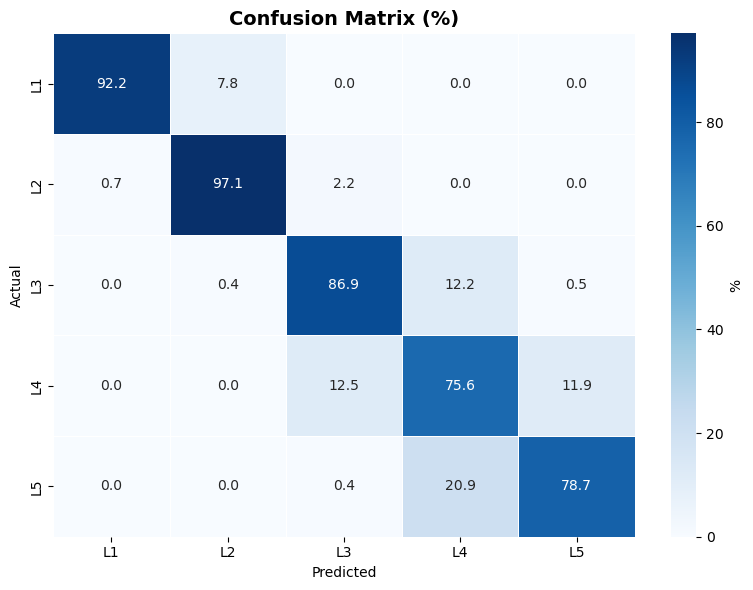

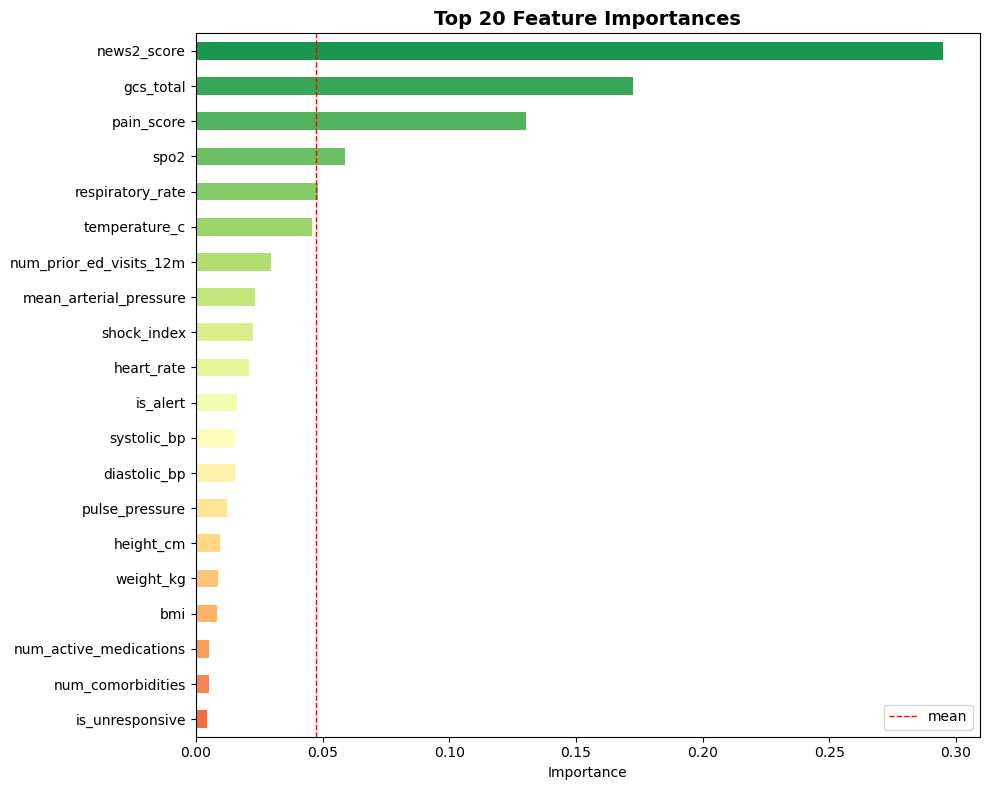

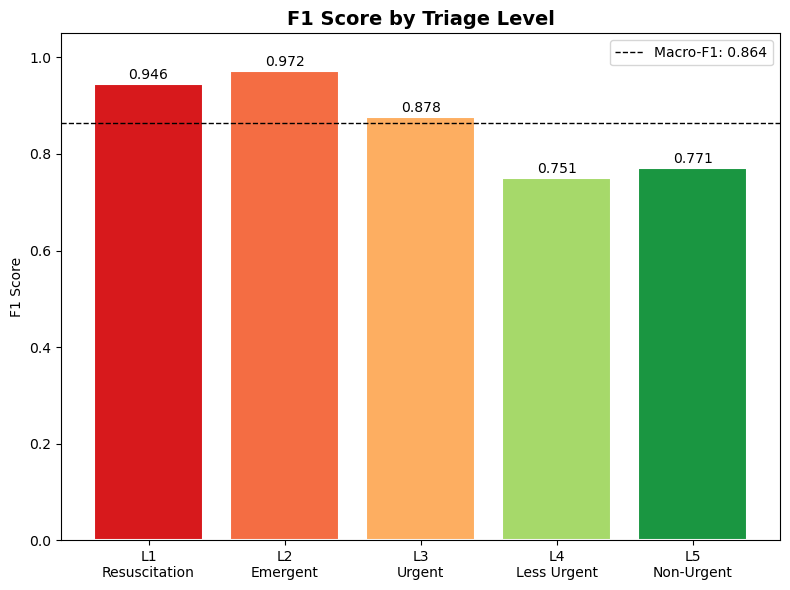

In [40]:
# manually set whatever params you want
rf_model = run_rf(train, max_depth=20, n_estimators=200, criterion="entropy", min_samples_split=10, max_features = 0.5)
